### Conexió

Realitza la connexió en Python amb el MySQL Workbench per a carregar tota la informació que tens en les taules.
Realitzaràs una visualització per a cada exercici. Comenta el que et crida l'atenció de graficar aquesta variable, justifica l'elecció del gràfic i interpreta els resultats en funció de les teves dades.

In [ ]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt


import mysql.connector
from mysql.connector import Error

try:
    connection = mysql.connector.connect(
        host="localhost",
        user="root",
        password="45913219-2Mysq",
        database="sprint4"
    )

    if connection.is_connected():
        db_Info = connection.get_server_info()
        print("Connected to MySQL Server version", db_Info)
        cursor = connection.cursor()
        cursor.execute("SELECT DATABASE();")
        record = cursor.fetchone()
        print("You're connected to database:", record)

        cursor.execute("SHOW TABLES")
        tabelas = cursor.fetchall() #fetchall coge nombre de tabla, (comma), valor vacio
        print("You have those tables:", tabelas) 

        for (tabela,) in tabelas:
            query = f"SELECT * FROM {tabela}"
            globals()[f"{tabela}_df"] = pd.read_sql(query, con=connection)
            print(f"Tabela '{tabela}' importada con nombre de {tabela}_df.")
except Error as e:
    print("Erro ao conectar ao MySQL:", e)

finally:
    if connection.is_connected():
        cursor.close()
        connection.close()
        print("Conexão com MySQL encerrada.")

: 

In [6]:
#transformations
credit_cards_df = credit_cards_df.rename(columns={'id': 'cc_id'})
cc_df = credit_cards_df
products_df = products_df.rename(columns={'id': 'product_id'})
transactions_df = transactions_df.rename(columns={'id': 'transaction_id', 'card_id': 'cc_id', 'business_id': 'company_id'})
users_df = users_df.rename(columns={'id':'user_id'})
transactions_df['year'] = transactions_df['timestamp'].dt.year
transactions_df['year_month'] = transactions_df['timestamp'].dt.to_period('M')
transactions_df['month'] = transactions_df['timestamp'].dt.month
transactions_df['day'] = transactions_df['timestamp'].dt.day

### **Nivel 1**

#### Exercici 1: Una variable numèrica.

• **Liberia:** Pandas  
• **Grafico:** Histograma  
• **Variable numérica:** Amount  


**⦿ Comenta el que et crida l'atenció de graficar aquesta variable:**  
Saber cual es la frecuencia del valor de cada transacción, o sea, si las compras tienen un valor total recurrente

**⦿ Justifica l'elecció del gràfic:**  
Graficos en barras son ideales para 1 categoria numérica porque representam um count (frequency) por la variable numérica que tengas (amount en este caso)

**⦿ Interpreta els resultats en funció de les teves dades:**  
Las transacciones (ventas de productos) tienen valor de entre + de 0 y 500 y están equilibradas en relación a cantidad de vendas hechas por valor total de esta venta, aunque haya un poco más de cantidad de ventas realizadas en el valor total de entre 400-500euros.

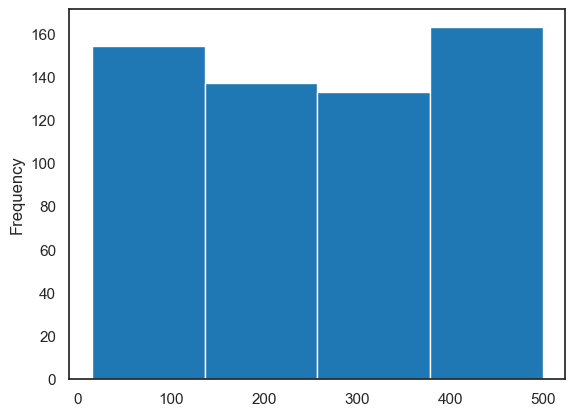

In [17]:
transactions_df["amount"].plot.hist(bins=4);

#### Exercici 2: Dues variables numèriques.

• **Liberia:** Seaborn  
• **Grafico:** Modelo Lineal  
• **Variables numéricas:** Precio y Peso de producto  


**⦿ Comenta el que et crida l'atenció de graficar aquesta variable:**  
Saber si el peso del producto influye en cuanto cuesta el mismo     

**⦿ Justifica l'elecció del gràfic:**  
El grafico de dispersión permite ver entre las duas variables (peso y precio) donde se concentran, por si se si concentran, los productos. He hecho con seaborn porque genera también una linea de regressión (de tendencia) con una superficie sombreada que és el intervalo de confianza de la regresión (mas estrecho al centro donde hay mas confianza y mas largo a las puntas porque hay mas incertidumbre, porque son valores extremos, sea para minimo o maximo)  

**⦿ Interpreta els resultats en funció de les teves dades:**  
Aunque que haya una linea de regresión que está un poco inclinada hacia arriba -lo que podría indicar que cuanto más pesa un producto más costoso és.
Como no se podía saber solo visualmente si la línea era suficientemente inclinada como para estabelecer esa relación, he buscado tests estadísticos y encontre OLS (Ordinary Least Squares) de statsmodel que calcula muchos coeficientes para si el peso de un producto predice su precio. Me enfoqué sobretodo en el P-value, que al ser de más de 0,05 demonstra que no hay una relación significativa (el valor és de 0.297)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.102
Date:                Sun, 29 Jun 2025   Prob (F-statistic):              0.297
Time:                        07:57:44   Log-Likelihood:                -549.92
No. Observations:                 100   AIC:                             1104.
Df Residuals:                      98   BIC:                             1109.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         88.2364     14.418      6.120      0.0

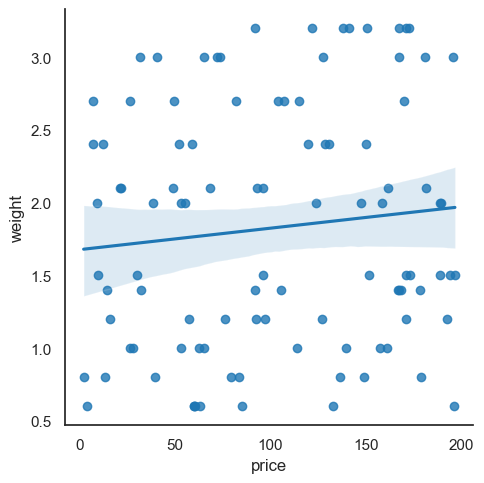

In [ ]:
sns.lmplot(data=products_df, x="price", y="weight");


"""
P-value
"""
X = products_df['weight']
y = products_df['price']
X = sm.add_constant(X)  # adiciona intercepto
modelo = sm.OLS(y, X).fit()
print(modelo.summary());

#### Exercici 3: Una variable categòrica.

• **Liberia:** Pandas  
• **Grafico:** Grafico de barras  
• **Variable categórica:** Países de las compañías  


**⦿ Comenta el que et crida l'atenció de graficar aquesta variable:**  
Tener una idea de cuantas empresas hay por país

**⦿ Justifica l'elecció del gràfic:**  
El grafico de barras verticales permite hacer una buena vizualización de una variable categorica a partir de un count en el eje opuesto

**⦿ Interpreta els resultats en funció de les teves dades:**  
Se puede conferir que hay empresas en 15 países diferentes en la base de datos y que el país que más tienes empresas és Sweden y el que menos es Spain.

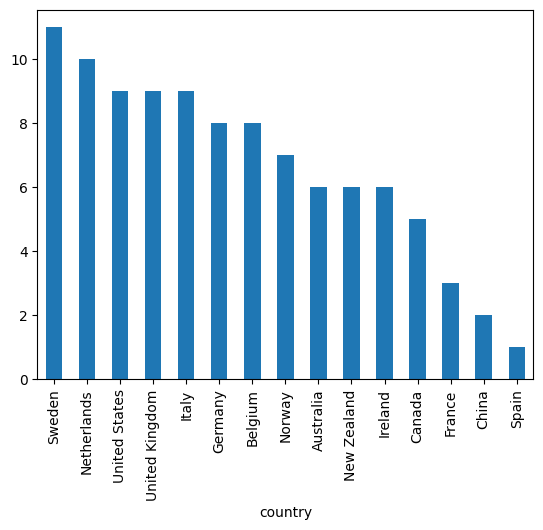

In [ ]:
companies_df["country"].value_counts().plot.bar(); # type: ignore

#### Exercici 4: Una variable categòrica i una numèrica.

• **Liberia:** Pandas  
• **Grafico:** Grafico de barras  
• **Variable categorica:** Declined  
• **Variable numérica:** Amount  


**⦿ Comenta el que et crida l'atenció de graficar aquesta variable:**  
Tener una idea de proporción entre el valor total de transaciones aceptadas o declinadas

**⦿ Justifica l'elecció del gràfic:**  
El grafico de barra hace un contraste entre la variable categórica (declined) e a numerica (amount).

**⦿ Interpreta els resultats en funció de les teves dades:**  
La suma de todas las transaciones aceptadas (0) es más o menos 6 veces más grande que la suma de las transaciones declinadas (1). El valor absoluto de las declinadas suma al rededor de 20000 euros.

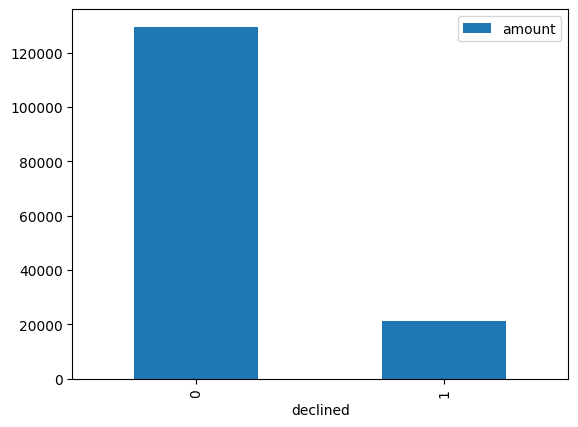

In [7]:
transactions_df.groupby("declined")[["amount"]].sum().plot.bar();

#### Exercici 5: Dues variables categòriques.

• **Liberia:** Pandas  
• **Grafico:** Grafico de barras en paralelo  
• **Variables categóricas:** Países de las compañías, declined  


**⦿ Comenta el que et crida l'atenció de graficar aquesta variable:**  
        Tener una idea de la relacion entre los usuarios, compartimentados por país, y las transacciones (si han sido aceptadas o declinadas), por cantidad de transaciones realizadas.

**⦿ Justifica l'elecció del gràfic:**  
        El grafico de barra agrupado hace un contraste importante entre las variable categóricas (usuarios-per-pais y declined) através de un count de transaciones.

**⦿ Interpreta els resultats en funció de les teves dades:**  
        Los usuarios de canada han hecho más cantidad de compras que de los otros países pero és el unico país que apresenta compras declinadas por sus usuários.

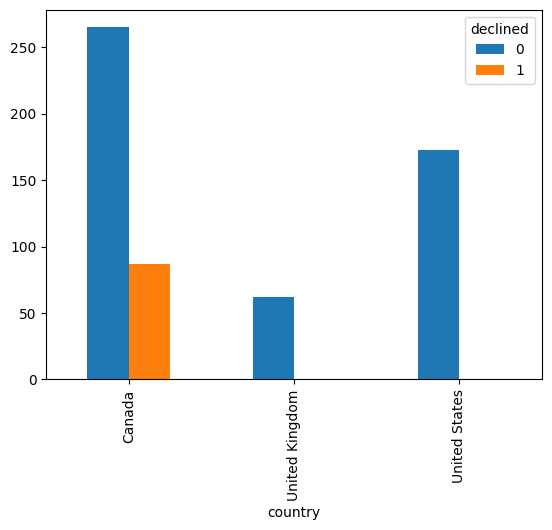

In [8]:
df = pd.merge(transactions_df, users_df, on ='user_id')
pd.crosstab(df["country"],df["declined"]).plot.bar();

#### Exercici 6: Tres variables.

• **Liberia:** Seaborn  
• **Grafico:** Grafico de relaciones (relplot)  
• **Variable numérica:** Amount  
• **Variables categóricas:** País, Declined, Mes_Año  


**⦿ Comenta el que et crida l'atenció de graficar aquesta variable:**  
        Tener una idea de la relacion entre las ventas por cada mes por amount, por si estaba declinada o no y por cada uno de los países.

**⦿ Justifica l'elecció del gràfic:**  
        El grafico de relacion en linea enseña el amount comprado por las empresas de cada país por los meses del año y cual es la relacion entre aceptadas y declinadas por cada uno de los países

**⦿ Interpreta els resultats en funció de les teves dades:**  
        Se puede concluir que Canada és el único país que tiene compras declinadas y hacer análises como el hecho de que en United Kingdom

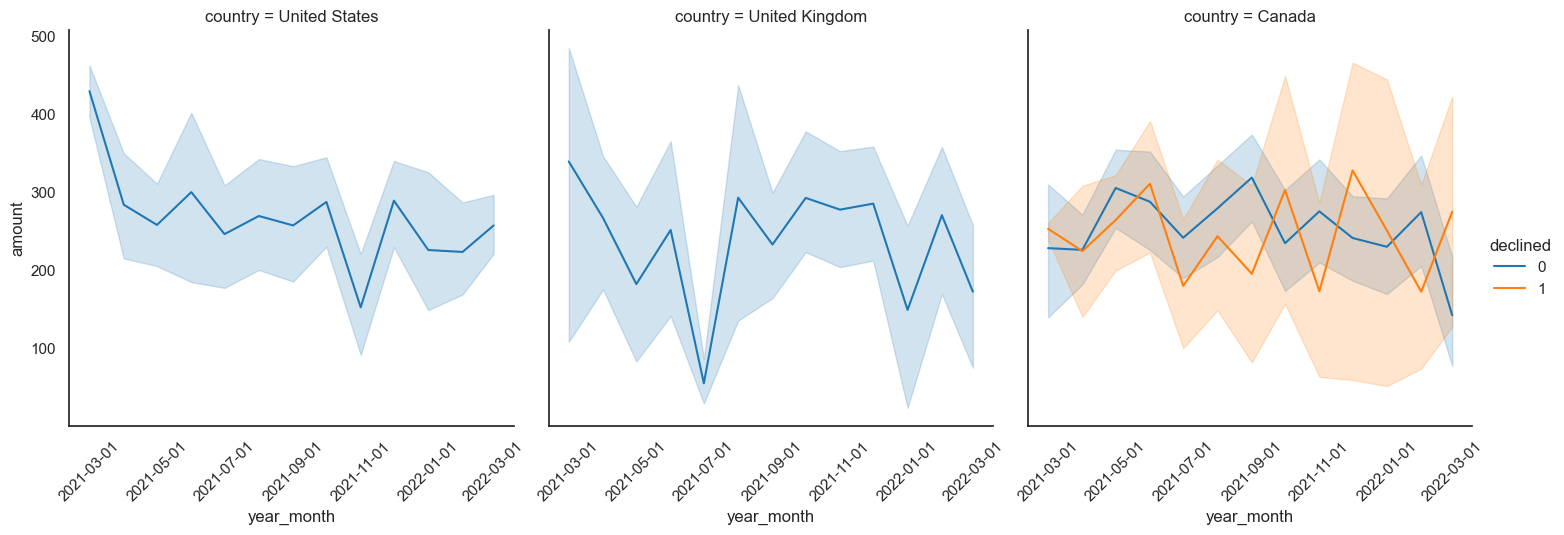

In [8]:
sns.set_theme(style="white", palette=None)
df = pd.merge(transactions_df, users_df, on ='user_id')
df['year_month'] = df['timestamp'].dt.to_period('M').dt.to_timestamp()


ax = sns.relplot(data=df, x="year_month", y="amount", hue="declined", kind="line", col="country", col_wrap=3)

ax.set_xticklabels(
    rotation = 45
);

##### **Extra por curiosidad**


• **Liberia:** Pandas  
• **Grafico:** Pivot Table 
• **Variable numérica:** Amount  
• **Variables categóricas:** País, Declined  


**⦿ Comenta el que et crida l'atenció de graficar aquesta variable:**  
        Poder saber no solo por dos variables categóricas (con un crosstab) pero sí con dos categóricas y una numérica, explorando también la visualizacioón del Amount de transaciones por cada País

**⦿ Justifica l'elecció del gràfic:**  
        El PivotTable permite resumir datos numéricos por grupos posibilitando comparar entre las variables categóricas

**⦿ Interpreta els resultats en funció de les teves dades:**  
        Gana más granularidad de información que el crosstable al añadir también el amount para el analisis.

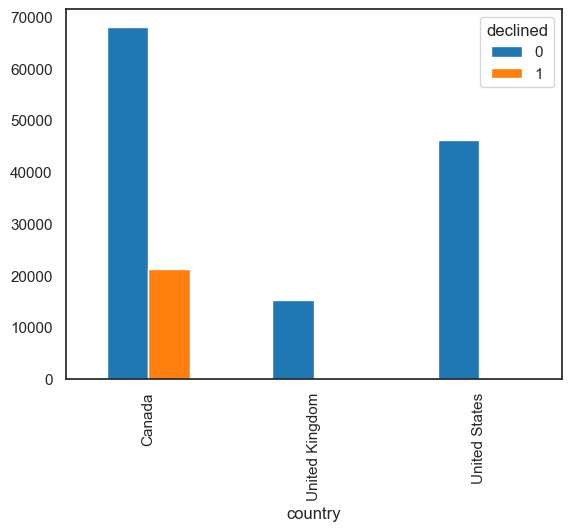

In [10]:
df = pd.merge(transactions_df, users_df, on ='user_id')
pd.pivot_table(df, index="country", columns="declined", values="amount", aggfunc="sum").plot.bar();

#### Exercici 7: Graficar un Pairplot.

• **Liberia:** Seaborn  
• **Grafico:** Pairplot  
• **Variable numérica:** Amount, Price, Weight  
• **Variables categóricas:** Declined  


**⦿ Comenta el que et crida l'atenció de graficar aquesta variable:**  
        Intentar comprender si hay alguna relacion entre ellas (valor total vendido, precio y peso)

**⦿ Justifica l'elecció del gràfic:**  
        Grafico pedido en el ejercicio ideal para comparacion entre pares numericos

**⦿ Interpreta els resultats en funció de les teves dades:**  
        Se puede avaliar que los productos de cerca de 2 quilos no cuestan más de 50 euros, y que los productos no son declinados especificamente por su precio o peso, ya que hay declined status por todo el grafico de manera no especifico.

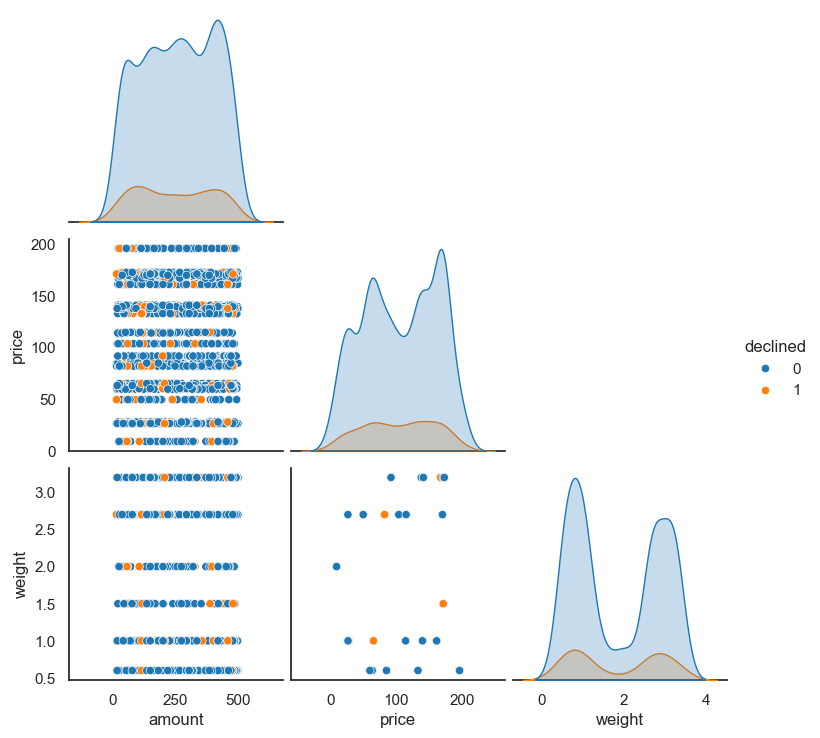

In [32]:
merged = transactions_df.merge(transactions_products_df, on='transaction_id').merge(products_df, on='product_id')
sns.pairplot(data=merged[['amount', 'price', 'weight', 'declined']],hue='declined', corner=True);

### **Nivel 2**

#### Exercici 1: Correlació de totes les variables numèriques.

• **Liberia:** Seaborn  
• **Grafico:** Pairplot  
• **Variable numérica:** Amount, Price, Weight  

**⦿ Comenta el que et crida l'atenció de graficar aquesta variable:**  
        Comprender la relación entre las variables numericas: si tienen correlacion positiva, neutra o negativa y en que intensidad.

**⦿ Justifica l'elecció del gràfic:**  
        Para variables numericas el mapa de calor puede ser una buena opción porque se puede detectar correlaciones entre dos variables

**⦿ Interpreta els resultats en funció de les teves dades:**  
        Las correlaciones que se establecen son muy debiles o nulas (entre -0.3 y 0.3). Una cosa interesante ha sido pensar cuales de las variables que eran números eran variables numéricas o no, y porqué. Un ejemplo ha sido lat y longitud que aunque sean numeros la interpreté como una variable categórica porque me dá la ubicación de las transaciones, bien como el año, mes y dia.  
        Como el heatmap usa el modelo de pearson por defecto, he tenido que verificar si mis datos eran normales o no. Si lo eran bastava usar el metodo de defecto de la funcion de correlacion. Pero si no eran datos normales deberia entonces usar el metodo de spearman, que no asume normalidad

In [34]:
from scipy.stats import shapiro

df = transactions_df.merge(transactions_products_df, on='transaction_id').merge(products_df, on='product_id').merge(companies_df, on='company_id').merge(credit_cards_df, on='cc_id')

matriz_correlacion = df[['amount', 'price', 'weight']]

for col in ['amount', 'price', 'weight']:
    stat, p = shapiro(matriz_correlacion[col])
    print(f'Columna: {col}')
    print('stat = %.3f, p = %.3f' % (stat, p))

    if p > 0.05:
        print('Probable distribución normal\n')
    else:
        print('Probablemente NO sigue distribución normal\n')


Columna: amount
stat = 0.947, p = 0.000
Probablemente NO sigue distribución normal

Columna: price
stat = 0.936, p = 0.000
Probablemente NO sigue distribución normal

Columna: weight
stat = 0.807, p = 0.000
Probablemente NO sigue distribución normal



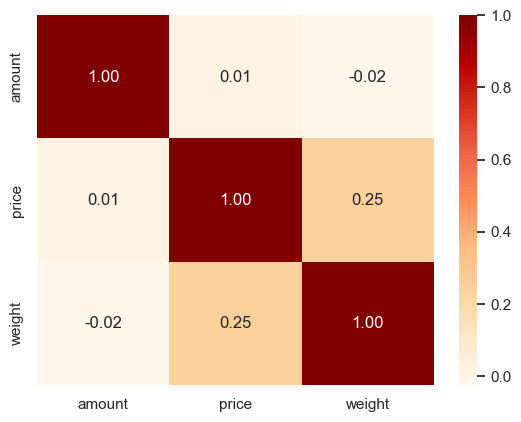

In [36]:
correlacion = matriz_correlacion.corr(method='spearman')

sns.heatmap(correlacion, annot=True, cmap='OrRd', fmt=".2f");

#### Exercici 2: Implementa un jointplot.

• **Liberia:** Seaborn  
• **Grafico:** Pairplot  
• **Variable numérica:** Amount, Price  
• **Variables categóricas:** User_Country  


**⦿ Comenta el que et crida l'atenció de graficar aquesta variable:**  
        Intentar comprender si hay algun patrón de compra en los usuarios across diferent countries

**⦿ Justifica l'elecció del gràfic:**  
        El grafico de joinplot permite avaliar las variables por como se comportan por si solas y como se relacionan

**⦿ Interpreta els resultats en funció de les teves dades:**  
        Se puede concluir que el valor total de una transacion no se correlaciona con valores altos de productos ya que los puntos de correlacion se distribuyen de manera igualitaria por todo el grafico.

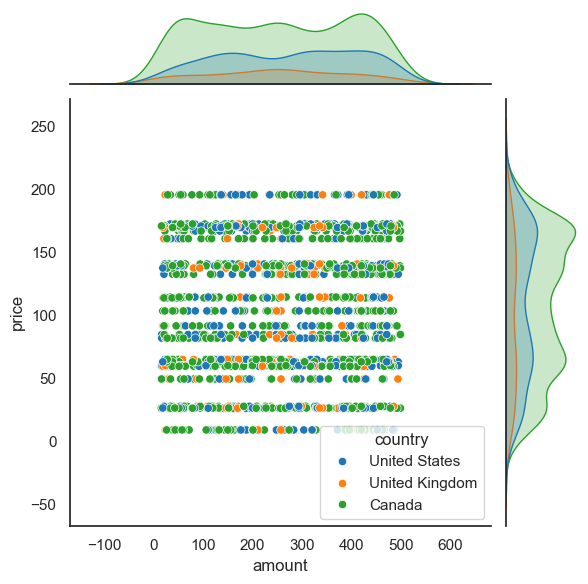

In [14]:
df = transactions_df.merge(users_df, on = 'user_id').merge(transactions_products_df, on='transaction_id').merge(products_df, on='product_id')
sns.jointplot(data=df, x='amount', y='price', hue='country');

### **Nivel 3**

#### Exercici 1: Implementa un violinplot combinat amb un altre tipus de gràfic.

• **Liberia:** Seaborn  
• **Grafico:** Violinplot  
• **Variable numérica:** Amount  
• **Variables categóricas:** Year, Declined 


**⦿ Comenta el que et crida l'atenció de graficar aquesta variable:**  
    Verificar cuales son los perfiles de las transacciones en cada año

**⦿ Justifica l'elecció del gràfic:**  
    El violin de Seaborn ya tiene integrado por defecto el BoxPlot dentro, lo que nos ayuda a ver de manera grafica los quartiles, mediana y outliers si hay. El violin enseña si hay más de un pico de datos por ejemplo, lo que no hace el boxplot, pero este ultimo complementa el primero dando informaciones de mediana y outliers que el violin no aporta.

**⦿ Interpreta els resultats en funció de les teves dades:**  
Se puede conferir que los amounts de las transaciones del año de 2022 fueran mas grandes que los amounts de las transaciones de 2022, que rondan en mediana cerca de los 200 mientras los de 2021 cerca de los 250. Con el hue declined se ha podido separar y conferir como se veen las transaciones declinadas en función de las aceptadas. En 2021 hay un volumen más alto de transaciones de pequeño valor declinadas que las aceptadas en este mismo recorte, y se nota que em ambos años las transaciones de menor y mayor aporte tienen mas volumen de declinadas que de aceptadas.

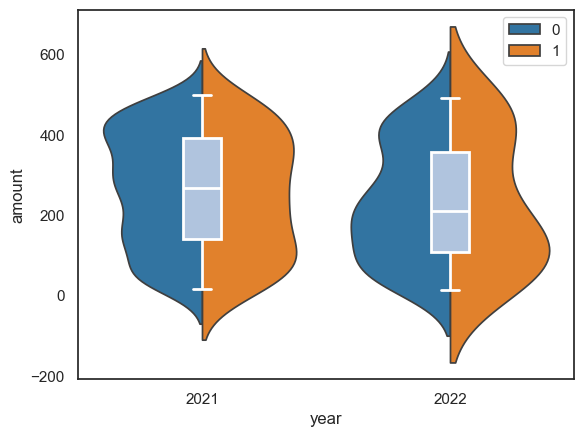

In [55]:
violin_plot = sns.violinplot(x='year', y='amount', hue='declined', split='true', data=transactions_df, inner=None)

sns.boxplot(
    x='year',
    y='amount',
    data=transactions_df,
    width=0.15,
    boxprops=dict(facecolor='lightsteelblue', edgecolor='white', linewidth=2),
    medianprops=dict(linewidth=2, color="white"),
    whiskerprops=dict(linewidth=2, color="white"),
    capprops=dict(color='white', linewidth=2),
    ax=violin_plot
);

#### Exercici 2: Genera un FacetGrid per a visualitzar múltiples aspectes de les dades simultàniament.

• **Liberia:** Seaborn  
• **Grafico:** FacetGrid Scatterplot  
• **Variable numérica:** Amount  
• **Variables categóricas:** Month, User_Country, Declined 

**⦿ Comenta el que et crida l'atenció de graficar aquesta variable:**  
    Buscar compreender el patrón de compra de los usuários al hacer un ScatterPlot de Amount x Mes y integrar un FacetGrid donde se puede separar por país de compra y por Declined.

**⦿ Justifica l'elecció del gràfic:**  
    La idea de usar el ScatterPlot viene por poder conferir los valores de compra mas/menos recurrentes para cada usuário de acuerdo con el país.

**⦿ Interpreta els resultats en funció de les teves dades:**  
    Se puede concluir entre otras cosas que Canada és el unico país que tiene transaciones declinadas; que United Kingdom tiene menor volumen de compra en relacion a los otros dos países y ambos United States y Kingdom en el mes 10 tienen compras de valor mínimos más elevadas que otros meses.

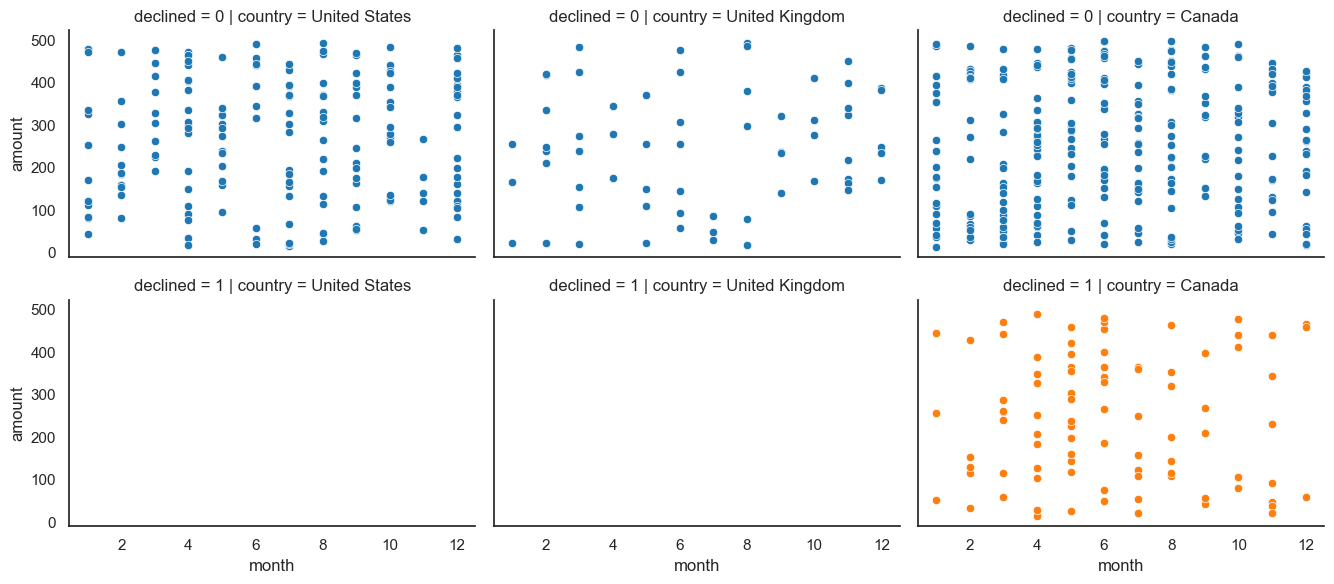

In [16]:
df = transactions_df.merge(users_df, on = 'user_id')

g = sns.FacetGrid(df, col="country",  row="declined", hue='declined', height=3, aspect=1.5)
g.map(sns.scatterplot, "month", "amount");